

 3 B

UCI Diabetes Dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Pima Diabetes Dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6       98             58             33      190  34.0   
1            2      112             75             32        0  35.7   
2            2      108             64     

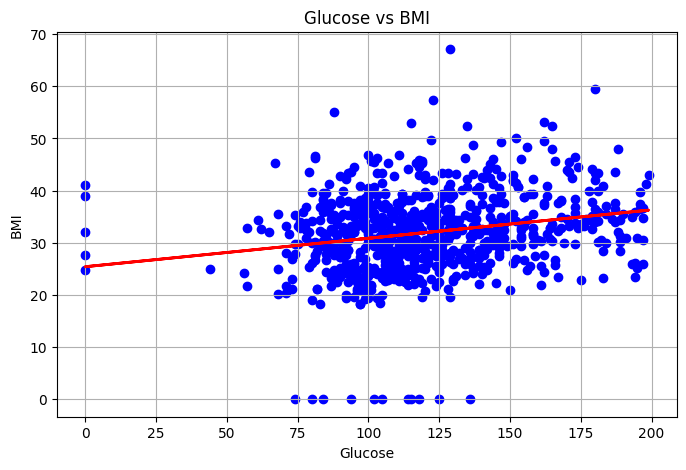


Linear Regression: Glucose -> BMI
R² Score: 0.0489


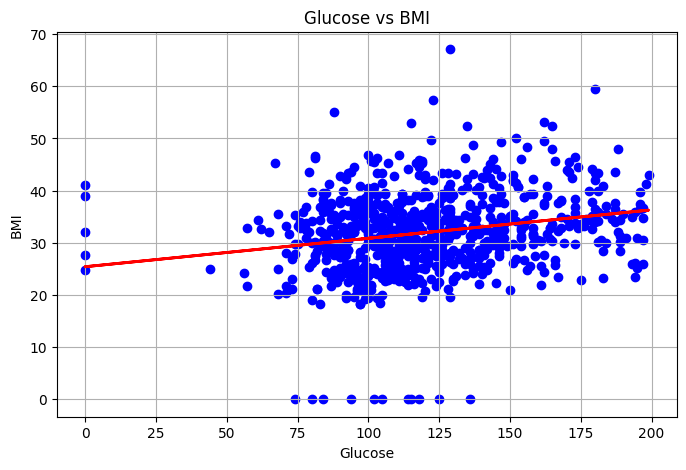


Logistic Regression using ['Glucose', 'BloodPressure', 'BMI', 'Age']
Accuracy: 0.7403

Logistic Regression using ['Glucose', 'BloodPressure', 'BMI', 'Age']
Accuracy: 0.7597


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

uci_diabetes = pd.read_csv(url)
pima_diabetes = pd.read_csv(url).sample(frac=1, random_state=42).reset_index(drop=True)

print("UCI Diabetes Dataset")
print(uci_diabetes.head())

print("\nPima Diabetes Dataset")
print(pima_diabetes.head())


def linear_regression_analysis(df, x_column, y_column):
    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression: {x_column} -> {y_column}")
    print(f"R² Score: {r2:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(X, Y, color="blue")
    plt.plot(X, Y_pred, color="red", linewidth=2)
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.grid(True)
    plt.show()


linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")


def logistic_regression_analysis(df, features, target):
    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print(f"\nLogistic Regression using {features}")
    print(f"Accuracy: {accuracy:.4f}")


features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age"
]

target = "Outcome"

logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)